# Multi Armed Bandits

# Smart ICU Treatment Dose Selection

## Problem Idea

### A hospital ICU must decide which oxygen dosage level to administer to critical patients.

* Each dosage level has:
    * Unknown probability of improving patient condition
    * Risk if overused
    * Limited budget/time

* Each dosage is treated as a bandit arm.

* Reward:
    * 1 → Patient stabilizes within 24 hours
    * 0 → No improvement

# Use Case: ICU Oxygen Dosage Optimization

### In critical care units (ICU), doctors often need to select the most effective oxygen dosage level for patients. However:

* True effectiveness probabilities are unknown.
* Trying all doses equally is risky.
* Sticking to one dose may miss better options.

### This is a classic Multi-Armed Bandit (MAB) problem.

### Each oxygen dosage level is treated as a bandit arm.

### The objective: Maximize number of stabilized patients.

#### Bandit vs MDP

| Multi-Armed Bandit   | Markov Decision Process |
| -------------------- | ----------------------- |
| No state transitions | Has states              |
| Single-step reward   | Sequential rewards      |
| No future dependency | Future depends on state |
| Simpler problem      | General RL framework    |

Bandits are special case of MDP with only one state.


#### Import Libraries and Env Setup (Synthetic ICU Simulation)

We simulate 5 oxygen dosage levels.

True success probabilities (unknown to agent):
true_probabilities = [0.35, 0.50, 0.65, 0.40, 0.55]

Dosage 3 (index 2) is best.

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
# Define number of arms (dosage levels)
n_arms = 5

# True success probabilities (hidden from agent)
true_probabilities = np.array([0.35, 0.50, 0.65, 0.40, 0.55])

# Total simulation steps (number of patients)
n_steps = 1000

#### Reward Function

In [3]:
def pull_arm(arm):
    """
    Simulates administering a dosage level.

    Parameters:
    arm (int): Index of selected dosage

    Returns:
    reward (int): 1 if patient stabilizes, else 0
    """

    # Generate random number between 0 and 1
    random_value = np.random.rand()

    # If random value < true success probability → reward 1
    if random_value < true_probabilities[arm]:
        return 1
    else:
        return 0

#### Greedy Algorithm

In [4]:
# Initialize estimated values (Q-values)
Q = np.zeros(n_arms)

# Track number of times each arm is selected
N = np.zeros(n_arms)

# Track total reward over time
rewards = []

for step in range(n_steps):

    # Select arm with highest estimated reward
    arm = np.argmax(Q)

    # Get reward from environment
    reward = pull_arm(arm)

    # Update selection count
    N[arm] += 1

    # Incremental mean update
    Q[arm] = Q[arm] + (1/N[arm]) * (reward - Q[arm])

    rewards.append(reward)

print("Estimated Values:", Q)

Estimated Values: [0.333 0.    0.    0.    0.   ]


Greedy exploits only.
If initial estimates are poor → stuck on wrong arm.

#### ε-Greedy Algorithm

In [5]:
epsilon = 0.1

Q = np.zeros(n_arms)
N = np.zeros(n_arms)
rewards_eps = []

for step in range(n_steps):

    # Exploration vs Exploitation
    if np.random.rand() < epsilon:
        arm = np.random.randint(n_arms)  # Explore
    else:
        arm = np.argmax(Q)  # Exploit

    reward = pull_arm(arm)

    N[arm] += 1

    Q[arm] = Q[arm] + (1/N[arm]) * (reward - Q[arm])

    rewards_eps.append(reward)

print("Estimated Values (ε-Greedy):", Q)

Estimated Values (ε-Greedy): [0.37878788 0.43243243 0.66331658 0.28571429 0.28571429]


In [6]:
epsilon = 0.01

Q = np.zeros(n_arms)
N = np.zeros(n_arms)
rewards_eps_1 = []

for step in range(n_steps):

    # Exploration vs Exploitation
    if np.random.rand() < epsilon:
        arm = np.random.randint(n_arms)  # Explore
    else:
        arm = np.argmax(Q)  # Exploit

    reward = pull_arm(arm)

    N[arm] += 1

    Q[arm] = Q[arm] + (1/N[arm]) * (reward - Q[arm])

    rewards_eps_1.append(reward)

print("Estimated Values (ε-Greedy):", Q)

Estimated Values (ε-Greedy): [0.34394904 0.         0.72222222 0.36363636 0.55387931]


In [10]:
epsilon = 0.05

Q = np.zeros(n_arms)
N = np.zeros(n_arms)
rewards_eps_3 = []

for step in range(n_steps):

    # Exploration vs Exploitation
    if np.random.rand() < epsilon:
        arm = np.random.randint(n_arms)  # Explore
    else:
        arm = np.argmax(Q)  # Exploit

    reward = pull_arm(arm)

    N[arm] += 1

    Q[arm] = Q[arm] + (1/N[arm]) * (reward - Q[arm])

    rewards_eps_3.append(reward)

print("Estimated Values (ε-Greedy):", Q)

Estimated Values (ε-Greedy): [0.35135135 0.44444444 0.42857143 0.33333333 0.52909091]


In [8]:
epsilon = 0.2

Q = np.zeros(n_arms)
N = np.zeros(n_arms)
rewards_eps2 = []

for step in range(n_steps):

    # Exploration vs Exploitation
    if np.random.rand() < epsilon:
        arm = np.random.randint(n_arms)  # Explore
    else:
        arm = np.argmax(Q)  # Exploit

    reward = pull_arm(arm)

    N[arm] += 1

    Q[arm] = Q[arm] + (1/N[arm]) * (reward - Q[arm])

    rewards_eps2.append(reward)

print("Estimated Values (ε-Greedy):", Q)

Estimated Values (ε-Greedy): [0.32075472 0.42105263 0.64146341 0.5106383  0.5952381 ]


UCB Action Selection

In [35]:
c = 2
Q = np.zeros(n_arms)
N = np.zeros(n_arms)
rewards_ucb = []

for step in range(n_steps):

    #UCB Action Selection

    ucb_values=Q+c* np.sqrt(np.log(step)/(N+1e-5))

    arm=np.argmax(ucb_values)

    reward = pull_arm(arm)

    N[arm] += 1

    Q[arm] = Q[arm] + (1/N[arm]) * (reward - Q[arm])

    rewards_ucb.append(reward)

print("Estimated Values (UCB Action Selection):", Q)

/tmp/ipykernel_530/3906971118.py:10: RuntimeWarning: divide by zero encountered in log
  ucb_values=Q+c* np.sqrt(np.log(step)/(N+1e-5))
/tmp/ipykernel_530/3906971118.py:10: RuntimeWarning: invalid value encountered in sqrt
  ucb_values=Q+c* np.sqrt(np.log(step)/(N+1e-5))


Estimated Values (UCB Action Selection): [0.36666667 0.50906892 0.64671473 0.38823529 0.54060914]


#### Comparative Performance

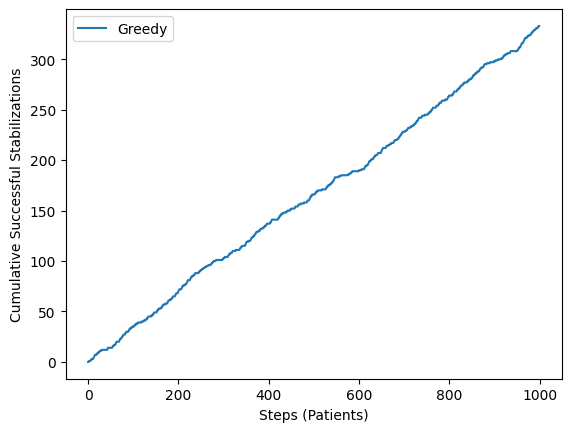

In [13]:
cumulative_eps1 = np.cumsum(rewards_eps_1)

cumulative_greedy = np.cumsum(rewards)
plt.plot(cumulative_greedy, label="Greedy")
plt.xlabel("Steps (Patients)")
plt.ylabel("Cumulative Successful Stabilizations")
plt.legend()
plt.show()

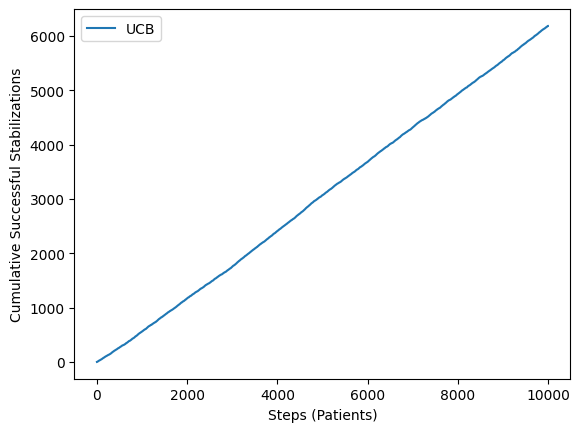

In [31]:
cumulative_ucb = np.cumsum(rewards_ucb)

plt.plot(cumulative_ucb, label="UCB")
plt.xlabel("Steps (Patients)")
plt.ylabel("Cumulative Successful Stabilizations")
plt.legend()
plt.show()

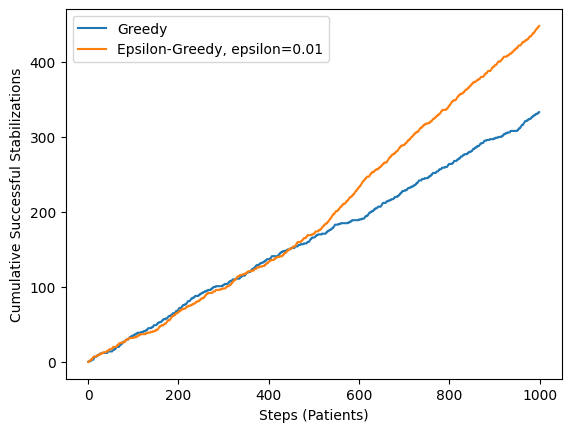

In [12]:
cumulative_eps1 = np.cumsum(rewards_eps_1)

cumulative_greedy = np.cumsum(rewards)
plt.plot(cumulative_greedy, label="Greedy")
plt.plot(cumulative_eps1, label="Epsilon-Greedy, epsilon=0.01")
plt.xlabel("Steps (Patients)")
plt.ylabel("Cumulative Successful Stabilizations")
plt.legend()
plt.show()

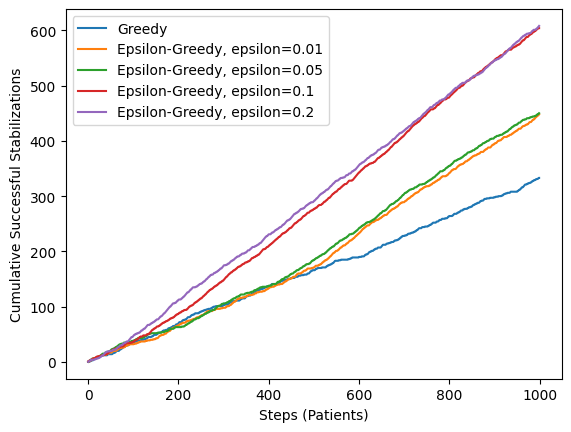

In [33]:
cumulative_greedy = np.cumsum(rewards)
cumulative_eps = np.cumsum(rewards_eps)
cumulative_eps1 = np.cumsum(rewards_eps_1)
cumulative_eps2 = np.cumsum(rewards_eps2)
cumulative_eps3 = np.cumsum(rewards_eps_3)


plt.plot(cumulative_greedy, label="Greedy")
plt.plot(cumulative_eps1, label="Epsilon-Greedy, epsilon=0.01")
plt.plot(cumulative_eps3, label="Epsilon-Greedy, epsilon=0.05")
plt.plot(cumulative_eps, label="Epsilon-Greedy, epsilon=0.1")
plt.plot(cumulative_eps2, label="Epsilon-Greedy, epsilon=0.2")
plt.xlabel("Steps (Patients)")
plt.ylabel("Cumulative Successful Stabilizations")
plt.legend()
plt.show()

#### Percentage Optimal Action

In [38]:
optimal_arm = np.argmax(true_probabilities)

optimal_selected = np.sum(np.array(np.argmax(Q) == optimal_arm))

print("True Best Dosage Index:", optimal_arm)
print("Estimated Best Dosage Index:", np.argmax(Q))

True Best Dosage Index: 2
Estimated Best Dosage Index: 2
